In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

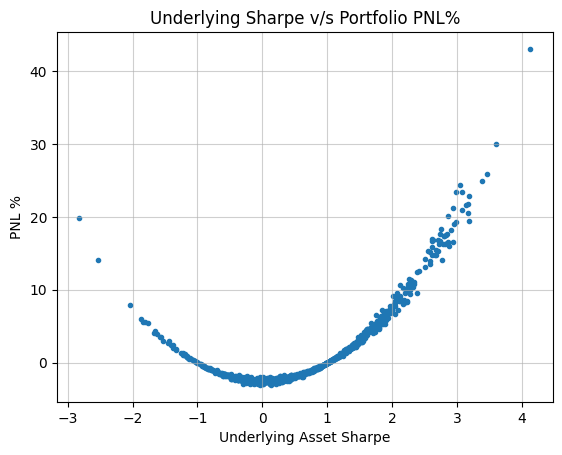

In [94]:
mu = 0.1
sigma = 0.15
initial_price = 100 
long_lev = 1.5
short_lev = 1.5
holding_period = int(252)

def run_sim(): 
    rng = np.random.default_rng()

    returns = rng.normal(loc=mu/252, scale=sigma/np.sqrt(252), size = holding_period)

    # asset_factor = np.cumprod(1 + returns)
    long_factor = np.cumprod(1 + (returns * long_lev))
    short_factor = np.cumprod(1 - (returns * short_lev))

    # asset = np.insert(initial_price * asset_factor, 0, initial_price)
    long = np.insert(initial_price * long_factor, 0, initial_price)  
    short = np.insert(initial_price * short_factor, 0, initial_price)

    portfolio = long + short 

    pnl = ((portfolio[-1]/portfolio[0]) - 1) * 100

    asset_sharpe = (returns.mean() * 252) / (returns.std() * np.sqrt(252))

    return (pnl, asset_sharpe)

fig, ax = plt.subplots() 
pnl = list()
sharpe = list()

for i in range(1000): 
    sim = run_sim() 
    pnl.append(sim[0])
    sharpe.append(sim[1])

ax.scatter(x=sharpe, y=pnl, marker='.')
ax.grid(alpha=0.6)
ax.set_xlabel("Underlying Asset Sharpe")
ax.set_ylabel("PNL %")
ax.set_title("Underlying Sharpe v/s Portfolio PNL%")
plt.show() 